<a href="https://colab.research.google.com/github/Garvitjaiswal12/car-price-prediction/blob/main/CarPricepredfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

In [4]:
df = pd.read_csv("CarPrice_Assignment.csv")

In [24]:
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [8]:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:")
display(categorical_columns)

Categorical Columns:


['CarName',
 'fueltype',
 'aspiration',
 'doornumber',
 'carbody',
 'drivewheel',
 'enginelocation',
 'enginetype',
 'cylindernumber',
 'fuelsystem']

In [ ]:
# Observations for Feature Selection:
# enginelocation: If 'rear' engines are significantly more expensive, this is a strong predictor.
# drivewheel: Look for price differences between 'rwd', 'fwd', and '4wd'.
# cylindernumber: Usually, more cylinders correlate with higher prices.
# carbody: Helps determine if certain styles (like convertibles) command a premium.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [12]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [14]:
df.duplicated().sum()

np.int64(0)

EDA

<Axes: xlabel='doornumber', ylabel='count'>

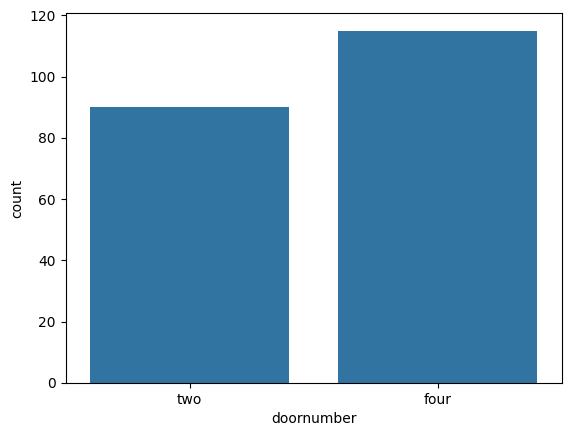

In [15]:
sns.countplot(x=df['doornumber'])

<Axes: xlabel='doornumber', ylabel='price'>

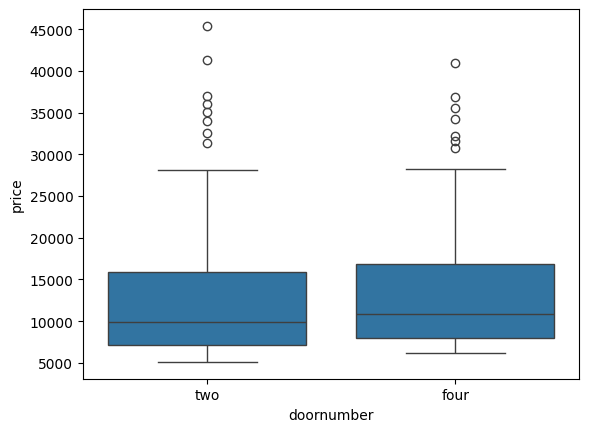

In [17]:
sns.boxplot(x=df['doornumber'],y=df['price'])

In [18]:
cat_col=['fueltype','aspiration','drivewheel','carbody']

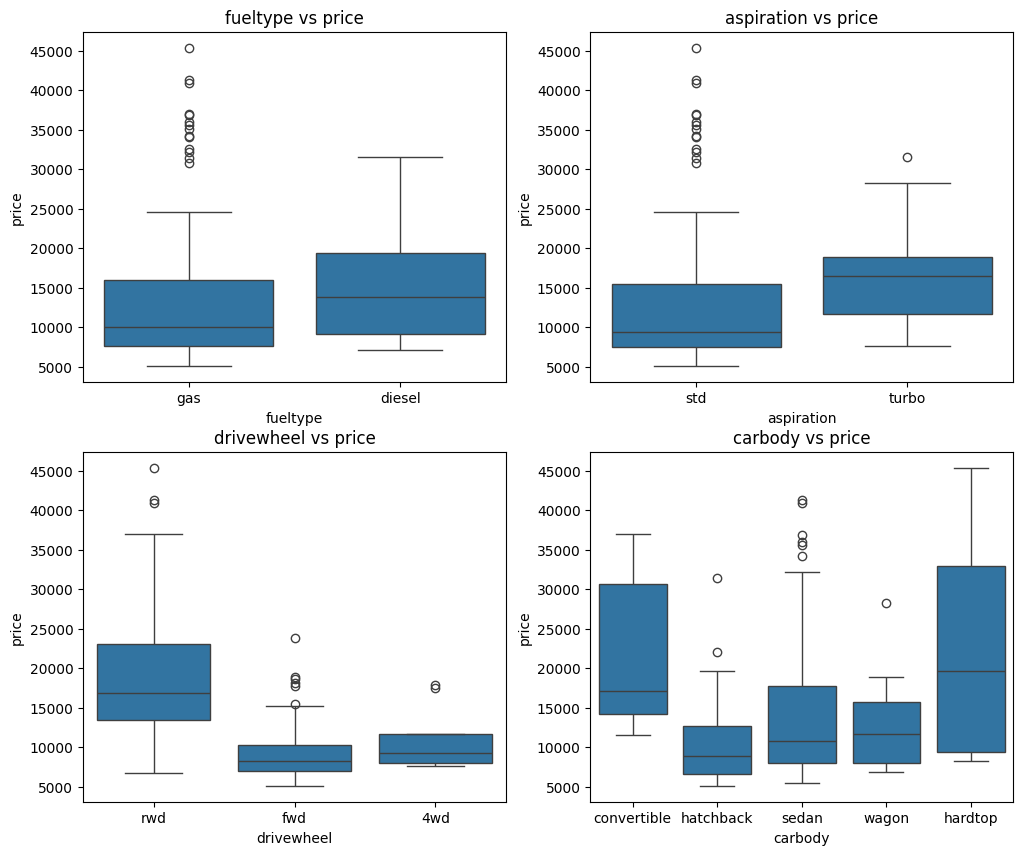

In [20]:
def boxplots(col,j):
  plt.subplot(2,2,j)
  sns.boxplot(x=col,y='price',data=df)
  plt.title(f"{col} vs price")

plt.figure(figsize=(12,10))

for i in range(len(cat_col)):
  boxplots(cat_col[i],i+1)

In [21]:
cat_col=['enginelocation','enginetype','cylindernumber','fuelsystem']

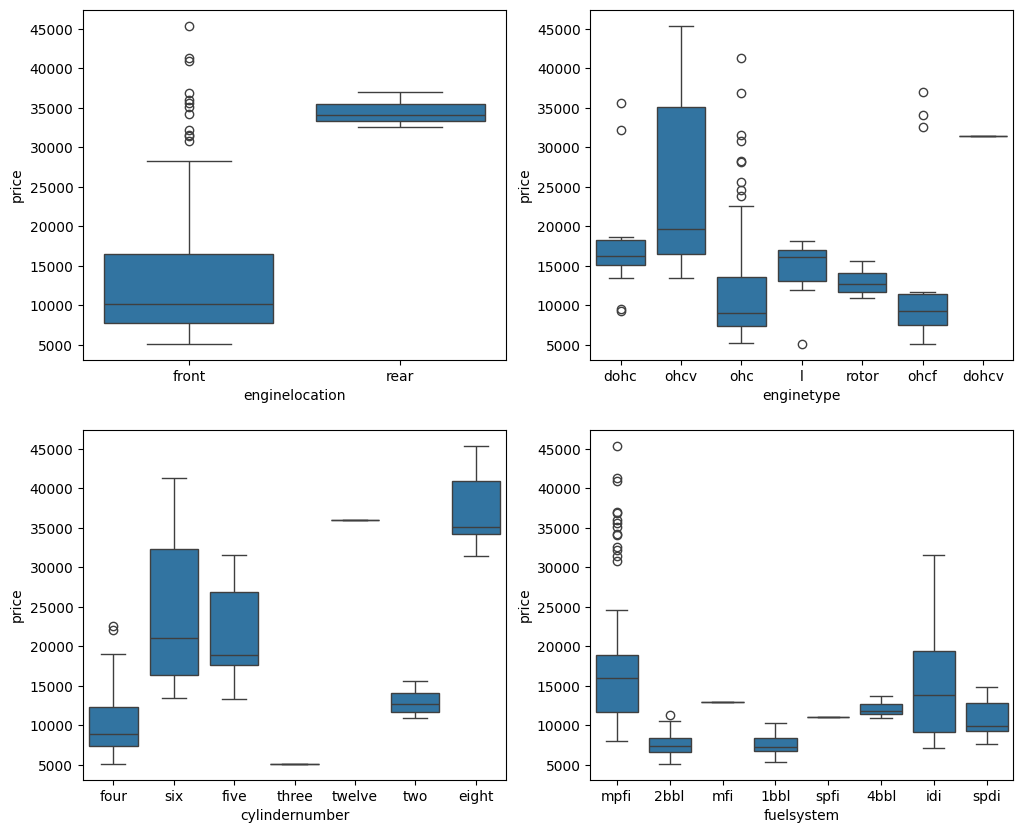

In [23]:
def boxplots(col,j):
  plt.subplot(2,2,j)
  sns.boxplot(x=col,y='price',data=df  )

plt.figure(figsize=(12,10))

for i in range(len(cat_col)):
  boxplots(cat_col[i],i+1)

continous columns


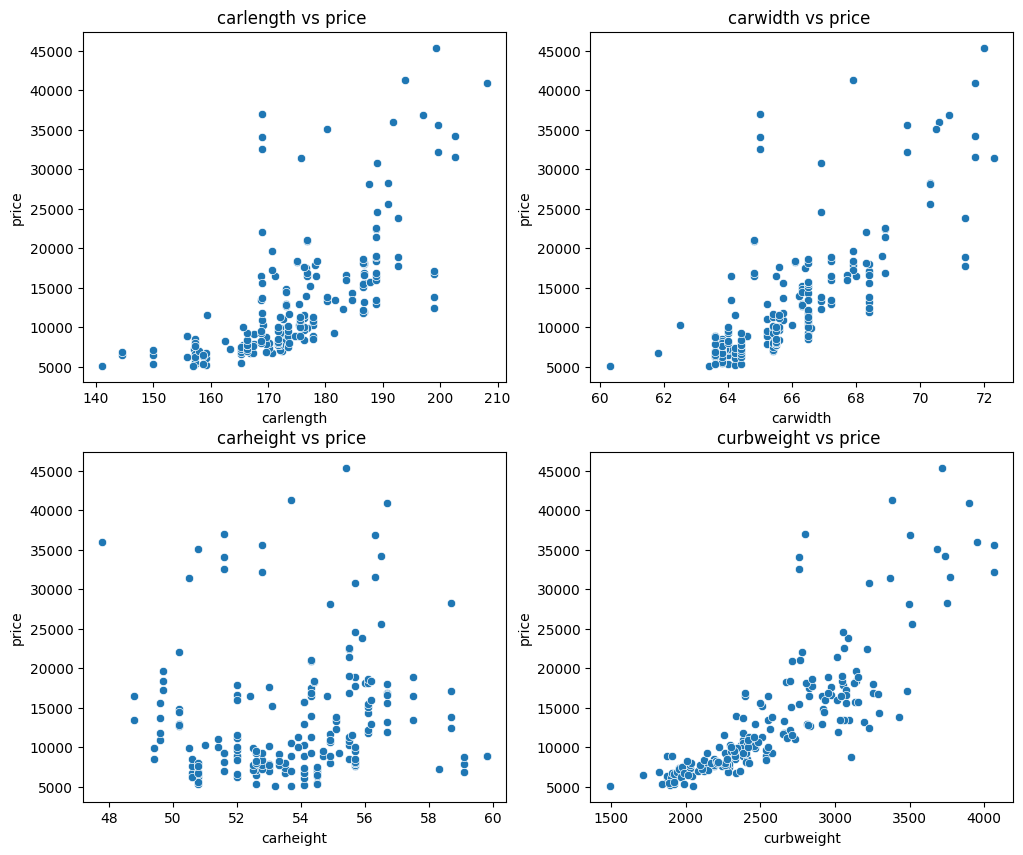

In [26]:
def scatter(x,fig):
  plt.subplot(2,2,fig)
  sns.scatterplot(x=df[x],y=df['price'])
  plt.title(x+" vs price ")

count=['carlength', 'carwidth', 'carheight', 'curbweight']
plt.figure(figsize=(12,10))

for i in range(len(count)):
  scatter(count[i],i+1)

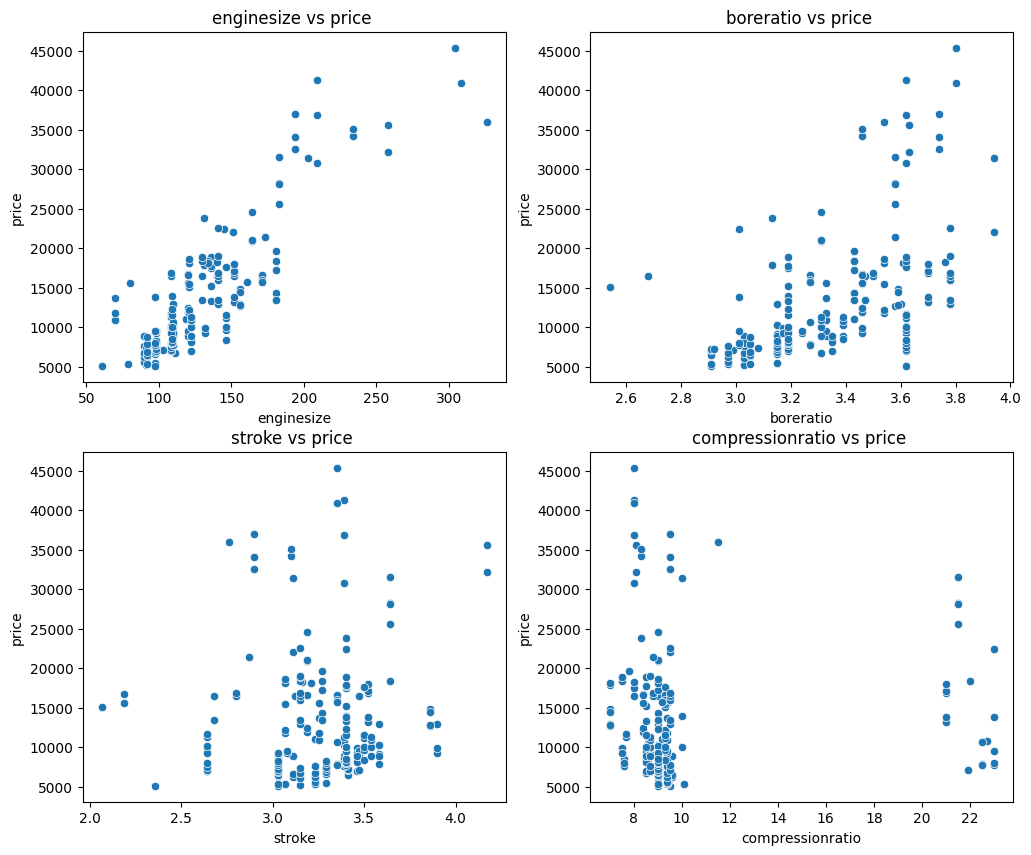

In [27]:
def scatter(x,fig):
  plt.subplot(2,2,fig)
  sns.scatterplot(x=df[x],y=df['price'])
  plt.title(x+" vs price ")

count=['enginesize','boreratio','stroke','compressionratio']
plt.figure(figsize=(12,10))

for i in range(len(count)):
  scatter(count[i],i+1)

<Axes: xlabel='wheelbase', ylabel='price'>

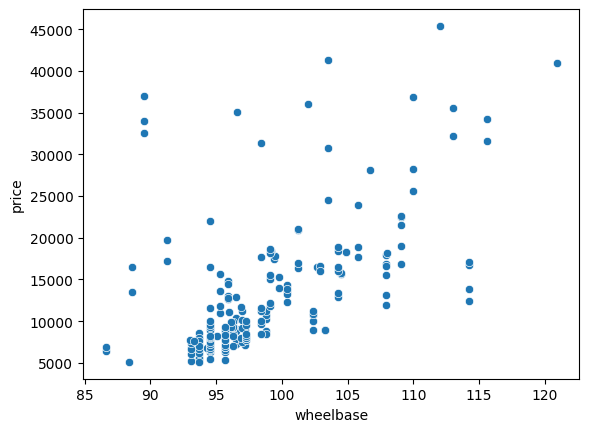

In [29]:
sns.scatterplot(x=df['wheelbase'],y=df['price'])

<Axes: xlabel='symboling', ylabel='price'>

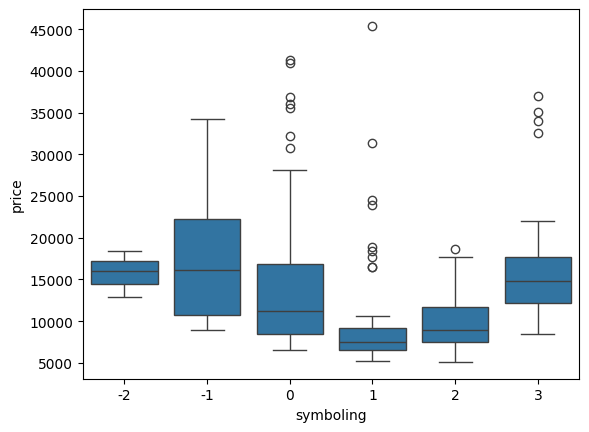

In [30]:
sns.boxplot(x=df['symboling'],y=df['price'])

<Axes: >

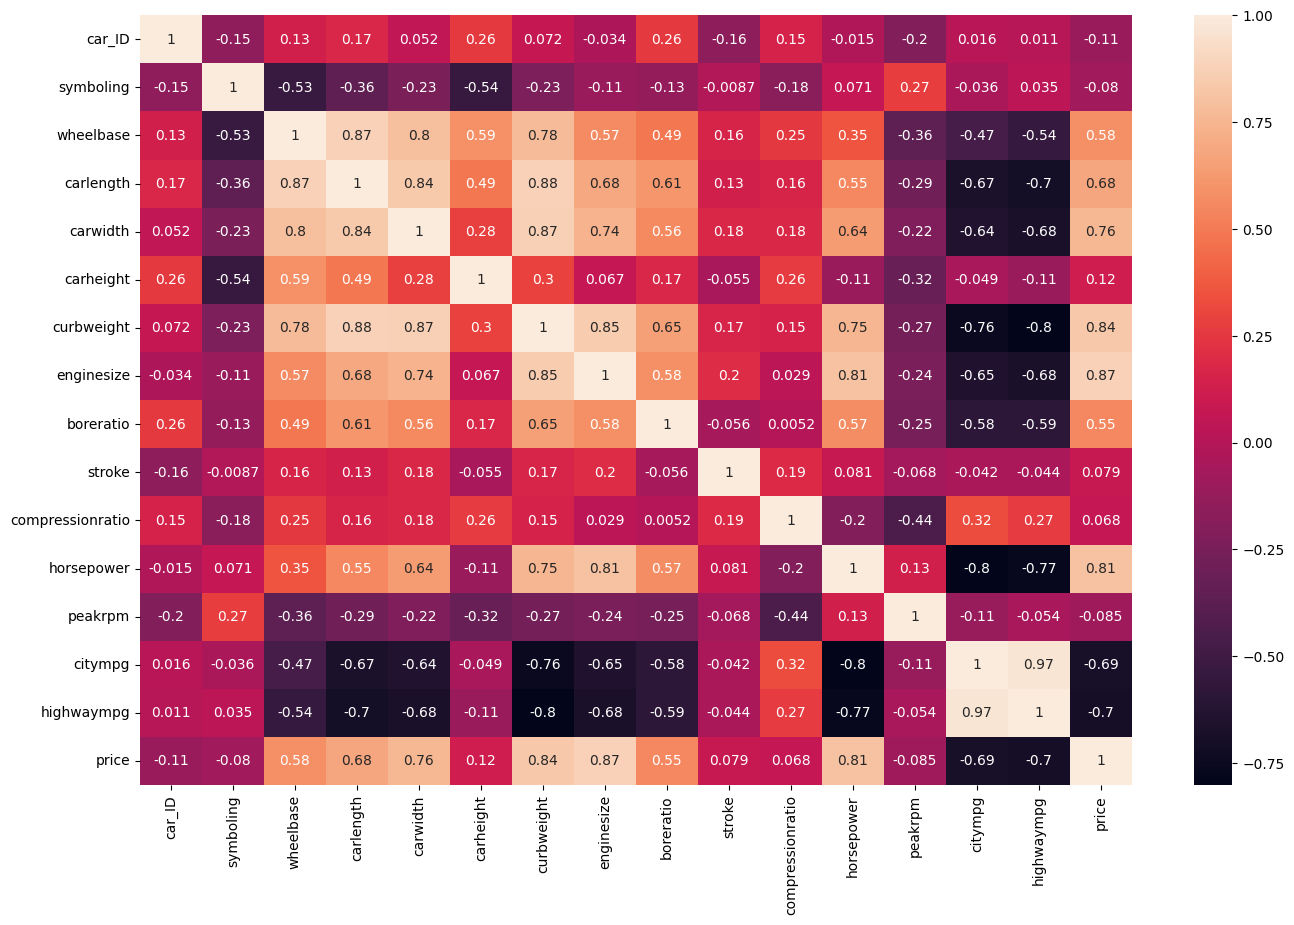

In [32]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)

"Categorical Columns:

"['CarName',❌

 'fueltype',⏰


 'aspiration',⏰

 'doornumber',❌

 'carbody',✅

 'drivewheel',✅

 'enginelocation',✅

 'enginetype',✅

 'cylindernumber',✅

 'fuelsystem'✅]


In [34]:
# useful features
car = df[[
    'symboling','wheelbase','carlength','carwidth','curbweight',
    'enginesize','horsepower','peakrpm','citympg',
    'carbody','drivewheel','enginelocation','enginetype','cylindernumber',
    'price'
]]

In [37]:
# # ---------------- ENCODING ---------------- #
car = pd.get_dummies(car ,drop_first=True)

In [38]:
car

,symboling,wheelbase,carlength,carwidth,curbweight,enginesize,horsepower,peakrpm,citympg,price,...,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,cylindernumber_five,cylindernumber_four,cylindernumber_six,cylindernumber_three,cylindernumber_twelve,cylindernumber_two
0,3,88.6,168.8,64.1,2548,130,111,5000,21,13495.0,...,False,False,False,False,False,True,False,False,False,False
1,3,88.6,168.8,64.1,2548,130,111,5000,21,16500.0,...,False,False,False,False,False,True,False,False,False,False
2,1,94.5,171.2,65.5,2823,152,154,5000,19,16500.0,...,False,False,True,False,False,False,True,False,False,False
3,2,99.8,176.6,66.2,2337,109,102,5500,24,13950.0,...,True,False,False,False,False,True,False,False,False,False
4,2,99.4,176.6,66.4,2824,136,115,5500,18,17450.0,...,True,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,109.1,188.8,68.9,2952,141,114,5400,23,16845.0,...,True,False,False,False,False,True,False,False,False,False
201,-1,109.1,188.8,68.8,3049,141,160,5300,19,19045.0,...,True,False,False,False,False,True,False,False,False,False
202,-1,109.1,188.8,68.9,3012,173,134,5500,18,21485.0,...,False,False,True,False,False,False,True,False,False,False
203,-1,109.1,188.8,68.9,3217,145,106,4800,26,22470.0,...,True,False,False,False,False,False,True,False,False,False


In [40]:
# # ---------------- SPLIT ---------------- #
X = car.drop('price', axis=1)
y = car['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
# # ---------------- SCALING ---------------- #
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # ✅ FIXED


In [43]:
# from sklearn.linear_model import LinearRegression
# linear_model=LinearRegression()

# linear_model.fit(X_train_scaled,y_train)

LinearRegression()

In [45]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [47]:
# y_prd=linear_model.predict(X_test_scaled)

In [48]:
r2=r2_score(y_test,y_prd)
mse=mean_squared_error(y_test,y_prd)
mae=mean_absolute_error(y_test,y_prd)

print(r2)
print(mse)
print(mae)

0.8686021448270809
10373075.022313166
2237.0601623474686


In [49]:
model = Ridge()
model.fit(X_train_scaled, y_train)

Ridge()

In [52]:
y_prd=model.predict(X_test_scaled)

In [53]:
r2=r2_score(y_test,y_prd)
mse=mean_squared_error(y_test,y_prd)
mae=mean_absolute_error(y_test,y_prd)

print(r2)
print(mse)
print(mae)

0.8690077542827703
10341054.580974232
2163.1705921197945


In [54]:
# ---------------- SAVE FILES ---------------- #
joblib.dump(model, "ridge_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")   # ✅ IMPORTANT

['columns.pkl']

In [55]:
# # ---------------- IMPORTS ---------------- #
# import pandas as pd
# import numpy as np
# import joblib

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import Ridge

# # ---------------- LOAD DATA ---------------- #
# df = pd.read_csv("CarPrice_Assignment.csv")

# # ---------------- SELECT FEATURES ---------------- #
# df = df[[
#     'symboling','wheelbase','carlength','carwidth','curbweight',
#     'enginesize','horsepower','peakrpm','citympg',
#     'carbody','drivewheel','enginelocation','enginetype','cylindernumber',
#     'price'
# ]]

# # ---------------- ENCODING ---------------- #
# df = pd.get_dummies(df, drop_first=True)

# # ---------------- SPLIT ---------------- #
# X = df.drop('price', axis=1)
# y = df['price']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # ---------------- SCALING ---------------- #
# scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)   # ✅ FIXED

# # ---------------- MODEL ---------------- #
# model = Ridge()
# model.fit(X_train_scaled, y_train)

# # ---------------- SAVE FILES ---------------- #
# joblib.dump(model, "ridge_model.pkl")
# joblib.dump(scaler, "scaler.pkl")
# joblib.dump(X.columns.tolist(), "columns.pkl")   # ✅ IMPORTANT

# print("✅ Model, Scaler, and Columns saved successfully!")